# Isolation Forest Anomaly Detection: Unexplained CPIS

## Purpose
Identify CPIS in arid SSA that are outliers across multiple water availability dimensions simultaneously: far from serviceable dams, uphill from surface water sources, and in areas with low groundwater productivity. These are the systems most worth investigating for undocumented water sources, unsustainable extraction, or
gaps in the underlying datasets.

## Context
This notebook is **Step 5 — the synthesis** of the water source attribution arc:

1. *CPIS expansion* — `Code/1_analyze_data`
2. *NDWI activity* — `5_ndwi_analysis.ipynb`
3. *Dam accessibility* — `6_dem_flow_analysis.ipynb`
4. *Groundwater correlation* — `7_groundwater_gp_regression.ipynb`
5. **Anomaly detection ← This notebook**
   After accounting for dam-accessible and groundwater-correlated CPIS, the
   remaining unexplained systems are the most scientifically interesting: they
   may have undocumented water sources, may be operating unsustainably, or may
   reveal gaps in the datasets. They mark where future fieldwork should focus.

Isolation Forest (Liu et al., 2008) isolates anomalies by randomly partitioning
the feature space. Anomalies require fewer partitions because they are sparse
relative to normal observations.

## Inputs
| Dataset | Config key | Notes |
|---------|-----------|-------|
| Dam-CPIS elevation profiles | `Dam_CPIS_Profiles_csv_path` | From notebook 6; recomputed if missing |
| CPIS groundwater values | `CPIS_GP_Groundwater_csv_path` | From notebook 5; falls back to nearest source-map value |
| Aridity raster | `Global_Aridity_Raster_path` | In repo |
| DEM (reprojected) | `Africa_Elevation_Reprojected_tif_path` | In repo |
| GDW dams | `GDW_Arid_SSA_Final_shp_path` | In repo |
| CPIS polygons | `SSA_Combined_CPIS_All_shp_path` | In repo |

## Outputs
| File | Config key | Description |
|------|-----------|-------------|
| `CPIS_Feature_Matrix.csv` | `CPIS_Feature_Matrix_csv_path` | Feature matrix used in anomaly detection |
| `CPIS_Anomaly_Scores.csv` | `CPIS_Anomaly_Scores_csv_path` | Anomaly scores and labels per CPIS |
| `CPIS_Anomalies.shp` | `CPIS_Anomalies_shp_path` | Shapefile of flagged anomalous CPIS |

In [1]:
# --- Import Required Libraries and Utilities ---
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from Code.utils.utility import load_config, resolve_path

config = load_config()

## Load CPIS Base Data

Features assembled for each CPIS:
| Feature | Proxy for |
|---------|----------|
| Distance to nearest dam (km) | Surface water proximity |
| Elevation diff: dam − CPIS (m) | Gravity-feed feasibility |
| Aridity index | Environmental water stress |
| Groundwater productivity | Groundwater availability |
| Elevation at CPIS centroid (m) | Terrain context |
| Log₁₀(CPIS area, m²) | System scale |

In [2]:
# --- Load CPIS base geometry and area ---
cpis = gpd.read_file(resolve_path(config['SSA_Combined_CPIS_All_shp_path']))
cpis = cpis.to_crs('EPSG:3857')
cpis['centroid_x'] = cpis.geometry.centroid.x
cpis['centroid_y'] = cpis.geometry.centroid.y
cpis['cpis_area_m2'] = cpis.geometry.area

print(f"CPIS loaded: {len(cpis):,}")
print(f"Area — mean: {cpis['cpis_area_m2'].mean():.0f} m², "
      f"range: [{cpis['cpis_area_m2'].min():.0f}, {cpis['cpis_area_m2'].max():.0f}] m²")

CPIS loaded: 29,482
Area — mean: 329522 m², range: [50, 5165130] m²


In [3]:
# --- Load elevation and dam proximity features ---
# Use precomputed profiles from notebook 6 if available; otherwise recompute.
profiles_path = resolve_path(config['Dam_CPIS_Profiles_csv_path'])

if os.path.isfile(profiles_path):
    print("Loading precomputed dam-CPIS profiles from notebook 6...")
    profiles = pd.read_csv(profiles_path, index_col=0)
    cpis = cpis.join(
        profiles[['nearest_dam_dist_m', 'elev_m', 'elev_diff_m']],
        how='left'
    )
    print(f"  Loaded profiles for {profiles['elev_m'].notna().sum():,} CPIS")
else:
    print("Profiles not found — recomputing from raw data.")
    print("(Run 6_dem_flow_analysis.ipynb first for precomputed results.)")

    dem_path = resolve_path(config['Africa_Elevation_Reprojected_tif_path'])
    dams = gpd.read_file(resolve_path(config['GDW_Arid_SSA_Final_shp_path'])).to_crs('EPSG:3857')

    cpis_coords = np.column_stack([cpis['centroid_x'], cpis['centroid_y']])
    dam_coords = np.column_stack([dams.geometry.x, dams.geometry.y])

    with rasterio.open(dem_path) as src:
        nd = src.nodata
        cpis_elvs = [v[0] for v in src.sample(cpis_coords.tolist())]
        dam_elvs  = [v[0] for v in src.sample(dam_coords.tolist())]

    cpis['elev_m'] = [np.nan if (nd and v == nd) else float(v) for v in cpis_elvs]
    dams['elev_m'] = [np.nan if (nd and v == nd) else float(v) for v in dam_elvs]

    tree = cKDTree(dam_coords)
    dist, idx = tree.query(cpis_coords, k=1)
    cpis['nearest_dam_dist_m'] = dist
    cpis['elev_diff_m'] = dams.iloc[idx]['elev_m'].values - cpis['elev_m']

print(f"Dam distance — mean: {cpis['nearest_dam_dist_m'].mean()/1000:.1f} km")

Loading precomputed dam-CPIS profiles from notebook 6...
  Loaded profiles for 29,482 CPIS
Dam distance — mean: 29.0 km


In [4]:
# --- Sample aridity index at CPIS centroids ---
aridity_path = resolve_path(config['Global_Aridity_Raster_path'])
cpis_ll = cpis.to_crs('EPSG:4326')
cpis_coords_ll = list(zip(cpis_ll.geometry.centroid.x, cpis_ll.geometry.centroid.y))

with rasterio.open(aridity_path) as src:
    nd_arid = src.nodata
    raw_aridity = [v[0] for v in src.sample(cpis_coords_ll)]

cpis['aridity_index'] = [
    float(v) if (v != nd_arid and v > 0) else np.nan
    for v in raw_aridity
]
print(f"Aridity index — mean: {cpis['aridity_index'].mean():.1f}, "
      f"range: [{cpis['aridity_index'].min():.0f}, {cpis['aridity_index'].max():.0f}]")

C:\Users\ermil\AppData\Local\Temp\ipykernel_28960\670643464.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cpis_coords_ll = list(zip(cpis_ll.geometry.centroid.x, cpis_ll.geometry.centroid.y))


Aridity index — mean: 2782.3, range: [143, 5000]


In [5]:
# --- Load groundwater productivity ---
# Use direct source-map groundwater values from notebook 5 if available; otherwise fall back
# to GP predictions or nearest-neighbor source values.
gp_csv = resolve_path(config['CPIS_GP_Groundwater_csv_path'])

if os.path.isfile(gp_csv):
    print("Loading CPIS groundwater productivity from notebook 5...")
    gp_df = pd.read_csv(gp_csv, index_col=0)
    # Both DataFrames were created from the same CPIS file in the same row order,
    # so aligning on the shared integer index is safe.
    shared_idx = cpis.index.intersection(gp_df.index)
    if len(shared_idx) == len(cpis) and 'source_gw_productivity' in gp_df.columns:
        cpis['gw_productivity'] = gp_df.loc[cpis.index, 'source_gw_productivity'].values
        print(f"  Direct source-map groundwater values loaded for {len(shared_idx):,} CPIS")
    elif len(shared_idx) == len(cpis) and gp_df['gp_gw_productivity'].nunique(dropna=True) > 1:
        cpis['gw_productivity'] = gp_df.loc[cpis.index, 'gp_gw_productivity'].values
        print(f"  GP predictions loaded for {len(shared_idx):,} CPIS")
    elif len(shared_idx) == len(cpis):
        print("  GP predictions are constant/stale - falling back to nearest source-map values")
        gp_df = None
    else:
        print(f"  Index mismatch ({len(shared_idx)} shared vs {len(cpis)} CPIS) — falling back to categorical")
        gp_df = None
else:
    print("GP predictions not found — using categorical MacDonald et al. data.")
    gp_df = None

if gp_df is None or ('gw_productivity' not in cpis.columns):
    gw = gpd.read_file(resolve_path(config['Groundwater_Prod_gpkg_path'])).to_crs('EPSG:4326')
    prod_col = [c for c in gw.columns
                if c.lower() in ('liters_second', 'litres_second', 'liter_second',
                                 'lps', 'gwprod', 'value', 'prod', 'productivity',
                                 'gw_prod', 'class')]
    prod_col = prod_col[0] if prod_col else [
        c for c in gw.columns
        if pd.api.types.is_numeric_dtype(gw[c])
        and c.lower() not in ('x', 'y', 'lon', 'lat', 'longitude', 'latitude')
        and c != 'geometry'
    ][0]
    gw_valid = gw[gw[prod_col] > 0].copy()
    gw_coords = np.column_stack([gw_valid.geometry.x, gw_valid.geometry.y])
    gw_tree = cKDTree(gw_coords)
    _, gw_idx = gw_tree.query(np.array(cpis_coords_ll), k=1)
    cpis['gw_productivity'] = gw_valid.iloc[gw_idx][prod_col].values.astype(float)
    print("  Categorical groundwater assigned (nearest-neighbor)")

print(f"Groundwater productivity — mean: {cpis['gw_productivity'].mean():.2f}")

Loading CPIS groundwater productivity from notebook 5...
  Direct source-map groundwater values loaded for 29,482 CPIS
Groundwater productivity — mean: 1.88


## Build and Save Feature Matrix

In [6]:
# --- Build feature matrix ---
feat_df = pd.DataFrame({
    'dist_dam_km':   cpis['nearest_dam_dist_m'] / 1000,
    'elev_diff_m':   cpis['elev_diff_m'],
    'aridity_index': cpis['aridity_index'],
    'gw_productivity': cpis['gw_productivity'],
    'elev_m':        cpis['elev_m'],
    'log_area_m2':   np.log10(cpis['cpis_area_m2'].clip(lower=1))
}, index=cpis.index)

# Require at least 4 of 6 features; drop rows with too many NaNs
feat_df_clean = feat_df.dropna(thresh=4).copy()

print(f"Feature matrix: {len(feat_df_clean):,} CPIS with sufficient features "
      f"(dropped {len(feat_df) - len(feat_df_clean):,} with too many missing values)")
print()
print(feat_df_clean.describe().round(2))

feat_path = resolve_path(config['CPIS_Feature_Matrix_csv_path'])
os.makedirs(os.path.dirname(feat_path), exist_ok=True)
feat_df_clean.to_csv(feat_path)
print(f"\nFeature matrix saved: {feat_path}")

Feature matrix: 29,482 CPIS with sufficient features (dropped 0 with too many missing values)

       dist_dam_km  elev_diff_m  aridity_index  gw_productivity    elev_m  \
count     29482.00     29482.00       29482.00         29482.00  29482.00   
mean         29.00         0.70        2782.27             1.88   1062.40   
std          46.11       111.85        1002.34             3.44    413.41   
min           0.03      -783.54         143.00             0.10     -1.10   
25%           8.71       -44.19        2022.25             0.30    933.82   
50%          18.70       -11.04        2676.00             0.75   1133.77   
75%          35.43        31.31        3648.00             0.75   1318.68   
max         630.66      1062.72        5000.00            20.00   2027.27   

       log_area_m2  
count     29482.00  
mean          5.42  
std           0.30  
min           1.70  
25%           5.21  
50%           5.41  
75%           5.63  
max           6.71  

Feature matrix saved:

## Fit Isolation Forest

`contamination=0.05` designates ~5% of samples as anomalies — a conservative starting point. Adjust based on domain knowledge of how many unexplained systems you expect.

`n_estimators=200` provides stable scores; `n_jobs=-1` uses all CPU cores.

In [7]:
# --- Isolation Forest ---
CONTAMINATION = 0.05

# Impute remaining NaNs with column medians before fitting
feat_imputed = feat_df_clean.fillna(feat_df_clean.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(feat_imputed)

iso = IsolationForest(
    n_estimators=200,
    contamination=CONTAMINATION,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)
iso.fit(X_scaled)

labels = iso.predict(X_scaled)   # -1 = anomaly, 1 = normal
scores = iso.score_samples(X_scaled)  # lower = more anomalous

feat_df_clean = feat_df_clean.copy()
feat_df_clean['anomaly_label'] = labels
feat_df_clean['anomaly_score'] = scores

n_anom = (labels == -1).sum()
print(f"Isolation Forest results:")
print(f"  Total CPIS analyzed: {len(labels):,}")
print(f"  Flagged as anomalies: {n_anom:,} ({100*n_anom/len(labels):.1f}%)")
print(f"  Normal CPIS:          {(labels == 1).sum():,}")

Isolation Forest results:
  Total CPIS analyzed: 29,482
  Flagged as anomalies: 1,475 (5.0%)
  Normal CPIS:          28,007


In [8]:
# --- Save scores and anomaly shapefile ---
scores_path = resolve_path(config['CPIS_Anomaly_Scores_csv_path'])
os.makedirs(os.path.dirname(scores_path), exist_ok=True)
feat_df_clean.to_csv(scores_path)
print(f"Anomaly scores saved: {scores_path}")

cpis_scored = cpis.loc[feat_df_clean.index].copy()
cpis_scored['anomaly_label'] = feat_df_clean['anomaly_label']
cpis_scored['anomaly_score'] = feat_df_clean['anomaly_score']

anomalies = cpis_scored[cpis_scored['anomaly_label'] == -1].copy()
normal_cpis = cpis_scored[cpis_scored['anomaly_label'] == 1].copy()

anom_path = resolve_path(config['CPIS_Anomalies_shp_path'])
os.makedirs(os.path.dirname(anom_path), exist_ok=True)
anomalies.drop(columns=['centroid_x', 'centroid_y'], errors='ignore').to_file(anom_path)
print(f"Anomaly shapefile saved: {anom_path} ({len(anomalies):,} features)")

Anomaly scores saved: C:/Users/ermil/Documents/Africa_Irrigation\Data/Processed/CPIS_Anomaly_Scores.csv


C:\Users\ermil\AppData\Local\Temp\ipykernel_28960\674709811.py:16: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  anomalies.drop(columns=['centroid_x', 'centroid_y'], errors='ignore').to_file(anom_path)


Anomaly shapefile saved: C:/Users/ermil/Documents/Africa_Irrigation\Data/Processed/CPIS_Anomalies-shp/CPIS_Anomalies.shp (1,475 features)


## Map Anomalous CPIS

Anomalous CPIS (red) are systems that are simultaneously unusual across distance-to-dam, elevation, aridity, groundwater, and area dimensions. These mark where follow-up investigation is most warranted.

C:\Users\ermil\AppData\Local\Temp\ipykernel_28960\2785444275.py:35: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axes[1].legend(fontsize=14, loc='lower left', framealpha=0.9)
C:\Users\ermil\AppData\Local\Temp\ipykernel_28960\2785444275.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(fontsize=14, loc='lower left', framealpha=0.9)


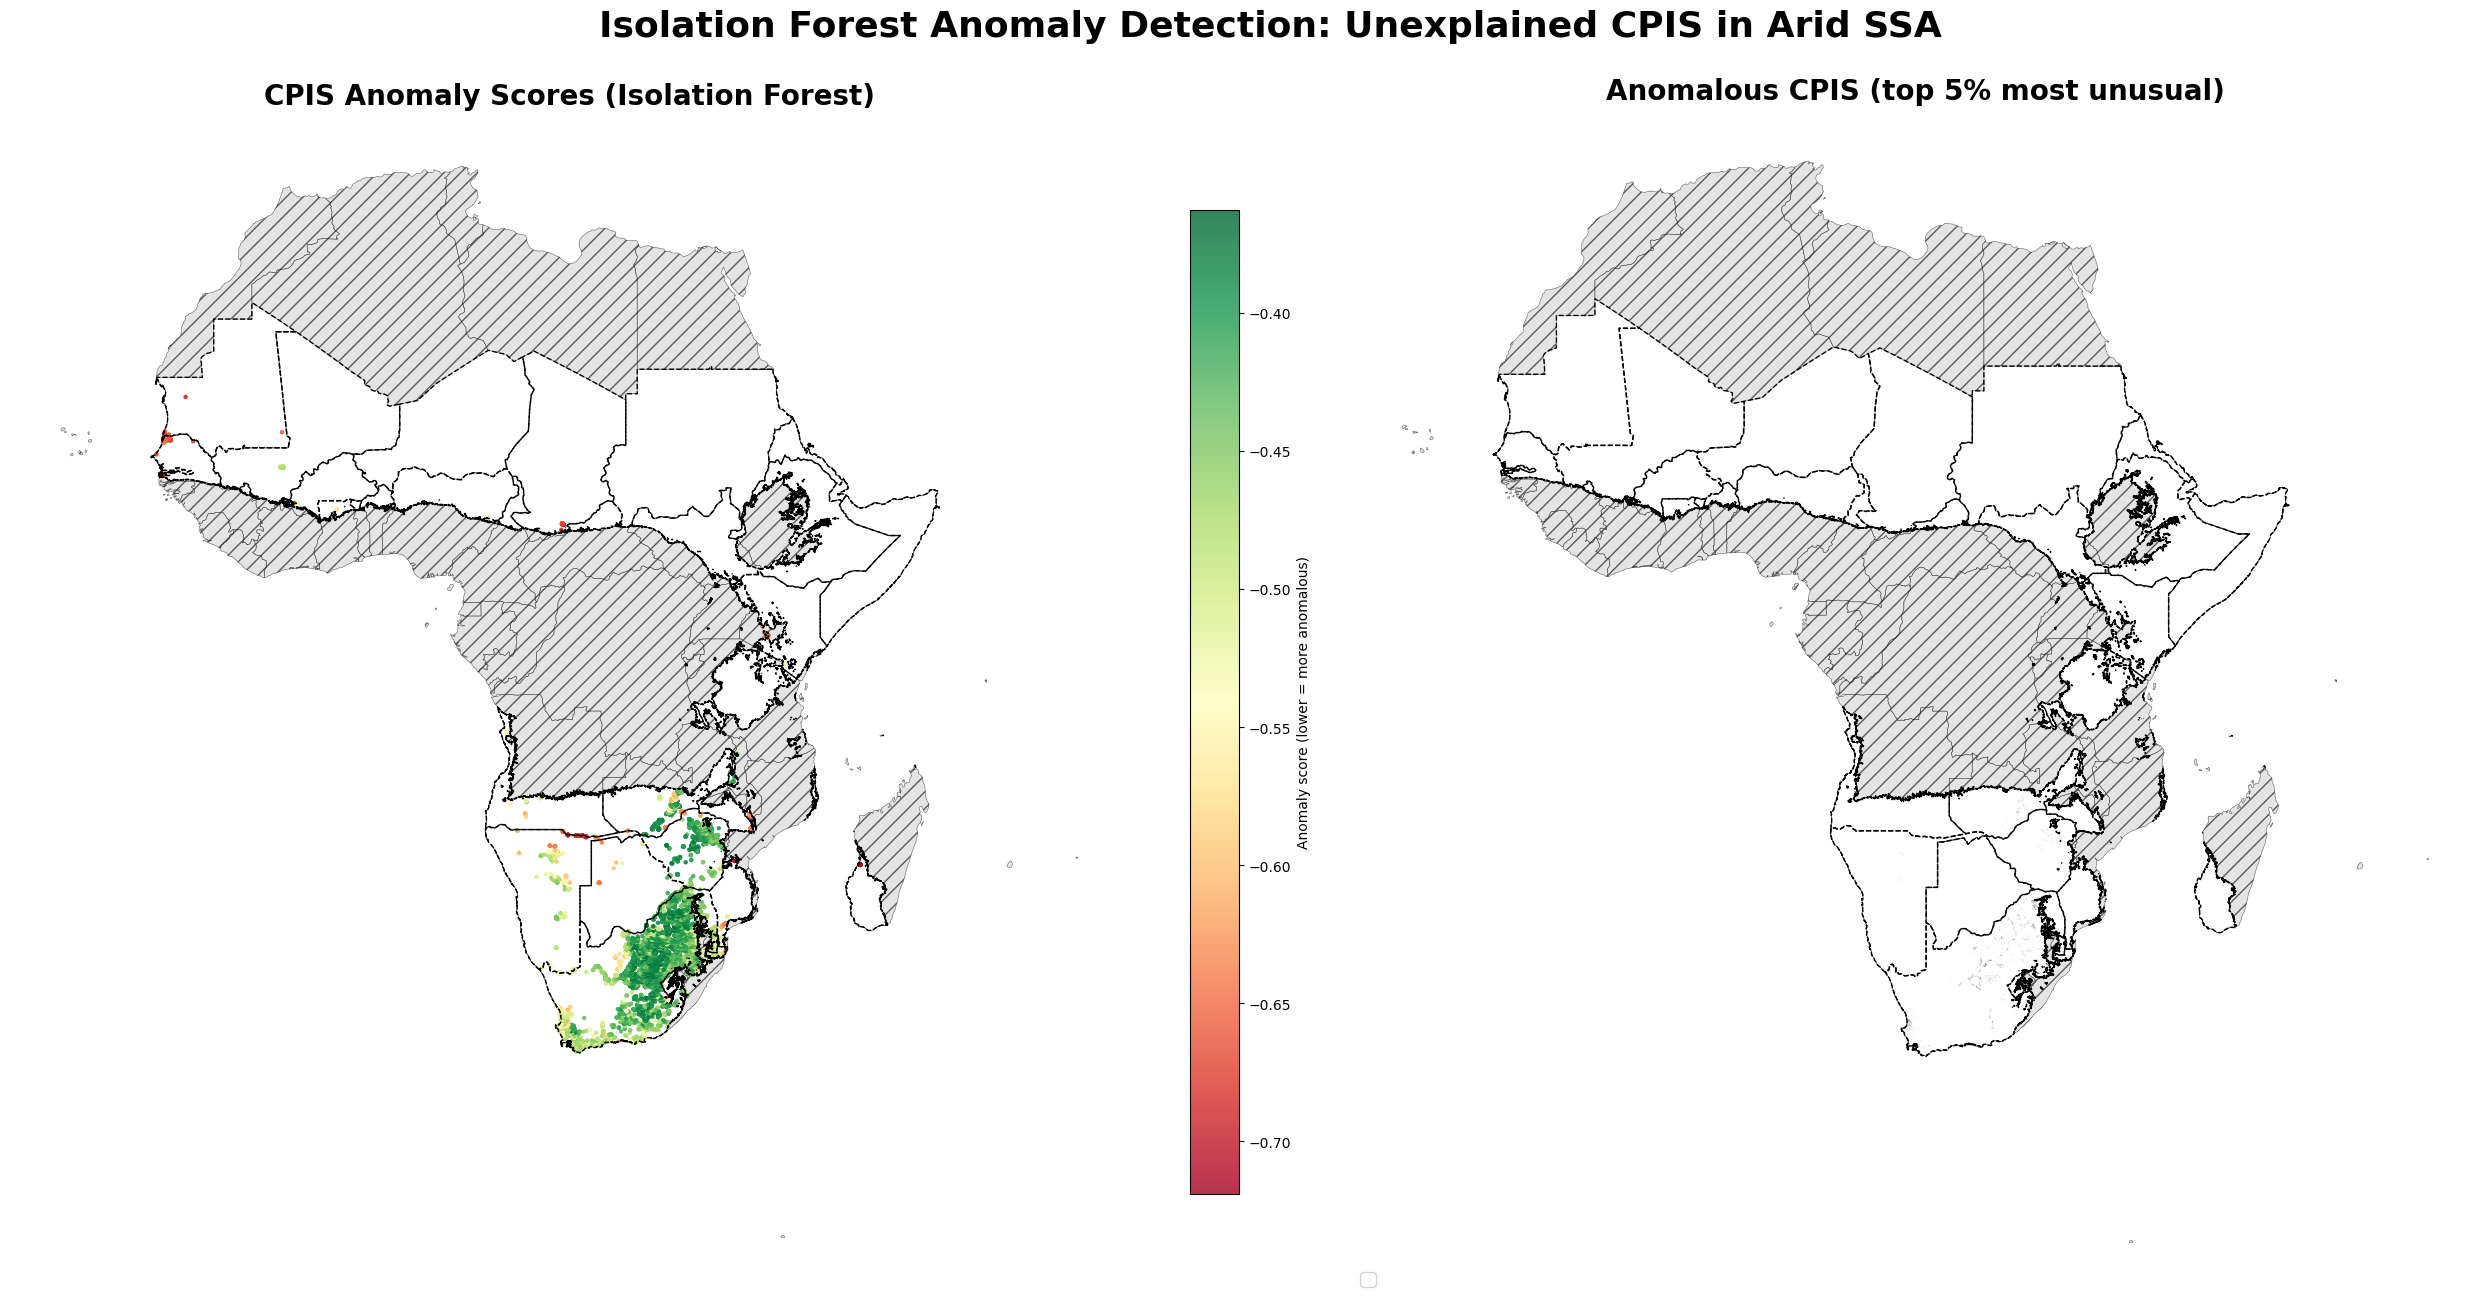

In [9]:
# --- Map anomalies ---
arid_ssa = gpd.read_file(resolve_path(config['SSA_All_by_Country_shp_path'])).to_crs('EPSG:3857')
arid_ssa['geometry'] = arid_ssa['geometry'].simplify(500)
af_bnds = gpd.read_file(resolve_path(config['Africa_boundaries_shp_path'])).to_crs('EPSG:3857')
af_bnds['geometry'] = af_bnds['geometry'].simplify(500)

fig, axes = plt.subplots(1, 2, figsize=(28, 14), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.05, left=0.05, right=0.95, top=0.9, bottom=0.05)

non_arid = af_bnds.overlay(arid_ssa, how='difference', keep_geom_type=False)

for ax in axes:
    non_arid.plot(ax=ax, color='lightgray', hatch='//', edgecolor='black',
                  linewidth=0.4, alpha=0.6)
    arid_ssa.boundary.plot(ax=ax, color='black', linewidth=1.0, linestyle='--')

# Panel 1: Continuous anomaly scores
sc = axes[0].scatter(
    cpis_scored.geometry.centroid.x, cpis_scored.geometry.centroid.y,
    c=cpis_scored['anomaly_score'], cmap='RdYlGn',
    s=5, norm=Normalize(vmin=scores.min(), vmax=scores.max()), alpha=0.8
)
plt.colorbar(sc, ax=axes[0], label='Anomaly score (lower = more anomalous)', fraction=0.04)
axes[0].set_title('CPIS Anomaly Scores (Isolation Forest)', fontsize=20, fontweight='bold')
axes[0].set_axis_off()

# Panel 2: Binary classification
normal_cpis.plot(ax=axes[1], color='#aaaaaa', markersize=3, alpha=0.6,
                 label=f'Normal ({len(normal_cpis):,})')
anomalies.plot(ax=axes[1], color='#d73027', markersize=8, alpha=0.9,
               label=f'Anomaly ({len(anomalies):,})')
axes[1].set_title(f'Anomalous CPIS (top {100*CONTAMINATION:.0f}% most unusual)',
                  fontsize=20, fontweight='bold')
axes[1].set_axis_off()
axes[1].legend(fontsize=14, loc='lower left', framealpha=0.9)

fig.suptitle('Isolation Forest Anomaly Detection: Unexplained CPIS in Arid SSA',
             fontsize=26, fontweight='bold', y=0.97)
plt.show()

## Interpret Anomalies

Which features drive the anomaly classification? Comparing feature distributions between anomalous and normal CPIS reveals which water availability dimensions are most responsible for flagging each group. Systems that are simultaneously far from dams, uphill, in dry areas, and in low-groundwater zones are the most critical cases for future fieldwork.

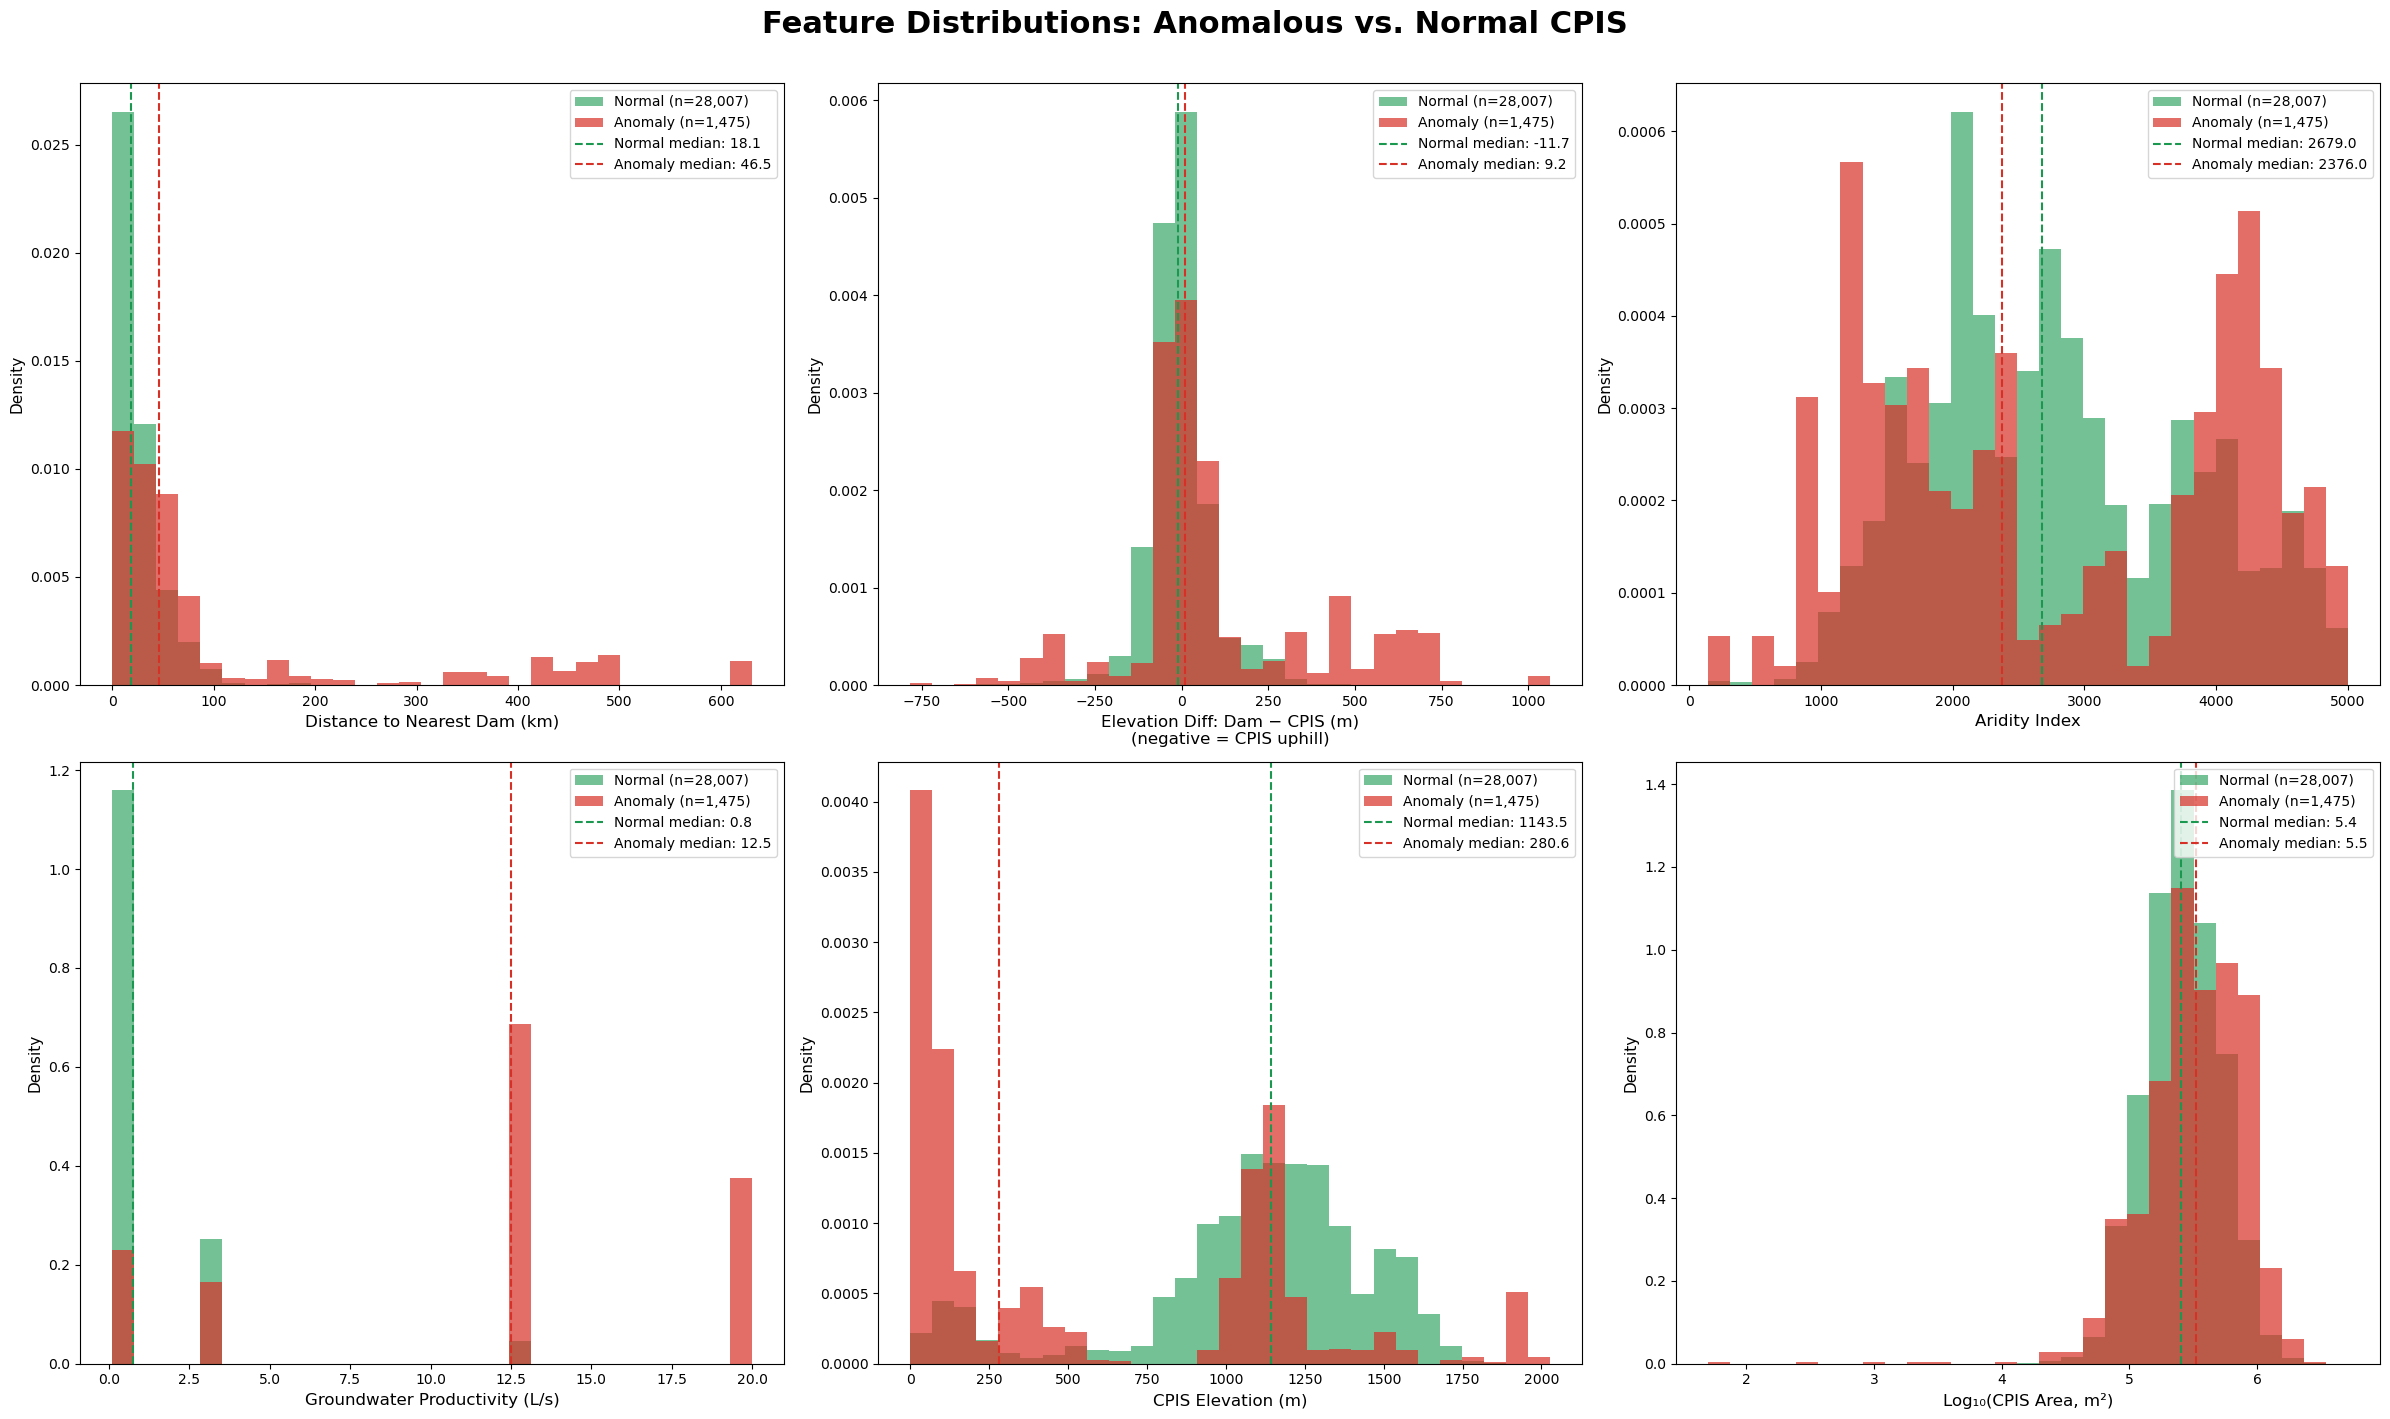

Median feature values — Normal vs. Anomaly:
                 normal_median  anomaly_median  difference
dist_dam_km              18.14           46.49       28.35
elev_diff_m             -11.69            9.19       20.88
aridity_index          2679.00         2376.00     -303.00
gw_productivity           0.75           12.50       11.75
elev_m                 1143.48          280.58     -862.90
log_area_m2               5.41            5.52        0.11


In [10]:
# --- Feature distribution comparison ---
feature_labels = {
    'dist_dam_km':    'Distance to Nearest Dam (km)',
    'elev_diff_m':    'Elevation Diff: Dam \u2212 CPIS (m)\n(negative = CPIS uphill)',
    'aridity_index':  'Aridity Index',
    'gw_productivity': 'Groundwater Productivity (L/s)',
    'elev_m':         'CPIS Elevation (m)',
    'log_area_m2':    'Log\u2081\u2080(CPIS Area, m\u00b2)'
}

normal_feat = feat_df_clean[feat_df_clean['anomaly_label'] == 1]
anom_feat   = feat_df_clean[feat_df_clean['anomaly_label'] == -1]

fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.ravel()

for ax, (col, label) in zip(axes, feature_labels.items()):
    nv = normal_feat[col].dropna()
    av = anom_feat[col].dropna()
    bins = np.linspace(
        min(nv.min(), av.min()), max(nv.max(), av.max()), 30
    )
    ax.hist(nv, bins=bins, alpha=0.6, color='#1a9850', density=True,
            label=f'Normal (n={len(nv):,})')
    ax.hist(av, bins=bins, alpha=0.7, color='#d73027', density=True,
            label=f'Anomaly (n={len(av):,})')
    ax.axvline(nv.median(), color='#1a9850', linestyle='--', linewidth=1.5,
               label=f'Normal median: {nv.median():.1f}')
    ax.axvline(av.median(), color='#d73027', linestyle='--', linewidth=1.5,
               label=f'Anomaly median: {av.median():.1f}')
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend(fontsize=10, loc='upper right')

fig.suptitle('Feature Distributions: Anomalous vs. Normal CPIS',
             fontsize=22, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Summary table
comparison = pd.DataFrame({
    'normal_median':  normal_feat[list(feature_labels.keys())].median(),
    'anomaly_median': anom_feat[list(feature_labels.keys())].median()
}).round(2)
comparison['difference'] = (comparison['anomaly_median'] - comparison['normal_median']).round(2)
print("Median feature values — Normal vs. Anomaly:")
print(comparison)